# 09 · Yapay veriyle kestirme öğrenmeyi kırmak

## Problem

06'da şunu bulmuştuk: model `drone` sınıfında mAP50 **0.94** alıyor ama bir İHA'yı kesip asfalta yapıştırdığımızda **göremiyor**. Aynı parçayı düz koyu bir zemine koyduğumuzda 0.91 güvenle tanıyor.

Teşhis: veri setindeki bütün İHA'lar tek kaynaktan (`uav2uav`) geliyor ve hepsinin arka planı gökyüzü. Model "İHA şekli" yerine **"düz koyu arka planda parlak leke"** kuralını öğrenmiş. Buna **kestirme öğrenme** (shortcut learning) denir.

08'de veri miktarını üç katına çıkardık (v2): genel başarı arttı ama kestirme **düzelmedi**. Çünkü eklenen veri de aynı türdendi. Sorun miktar değil, **çeşitlilik**.

## Çözüm fikri

Teşhis deneyinin kendisi çözümü de gösteriyor:

| | Ne yaptık |
|---|---|
| **Teşhis** | İHA'yı asfalta yapıştır → modele **sor** → "göremiyorum" |
| **Çözüm** | İHA'yı asfalta yapıştır → eğitime **ekle** → "artık biliyorum" |

Tek fark: bu sefer yanına **etiketini de** koyuyoruz. Nereye yapıştırdığımızı bildiğimiz için etiket bedava.

Literatürdeki adı **copy-paste augmentation**.

## 1. Hazırlık

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, random
from ultralytics import YOLO

klasor = "../data/kucuk_paket"

def oku(ad, bolum="train"):                                  # fotoğraf + etiket kutuları (piksel)
    foto = cv2.imread(f"{klasor}/images/{bolum}/{ad}.png")
    yukseklik, genislik = foto.shape[0], foto.shape[1]

    kutular = []
    with open(f"{klasor}/labels/{bolum}/{ad}.txt") as dosya:
        etiketler = dosya.read().splitlines()

    for satir in etiketler:
        p = satir.split()
        numara = int(p[0])                                   # sınıf numarası
        mx = float(p[1]) * genislik                          # oran → piksel (yatay)
        my = float(p[2]) * yukseklik                         # oran → piksel (dikey)
        g  = float(p[3]) * genislik
        y  = float(p[4]) * yukseklik
        kutular.append((numara,
                        round(mx - g/2), round(my - y/2),     # sol üst köşe
                        round(mx + g/2), round(my + y/2)))    # sağ alt köşe

    return foto, kutular

print("hazır")

hazır


## 2. Tek örnek: yapıştır ve etiketini yaz

Önce yöntemi tek bir fotoğrafta kuruyoruz. Kritik kısım **piksel → oran** dönüşümü: şimdiye kadar hep etiketi okurken oranı piksele çeviriyorduk, burada tersini yapıyoruz çünkü etiketi **biz yazıyoruz**.

```
okurken:   oran × boyut = piksel
yazarken:  piksel ÷ boyut = oran
```

üretilen etiket: 4 0.515625 0.815430 0.093750 0.068359


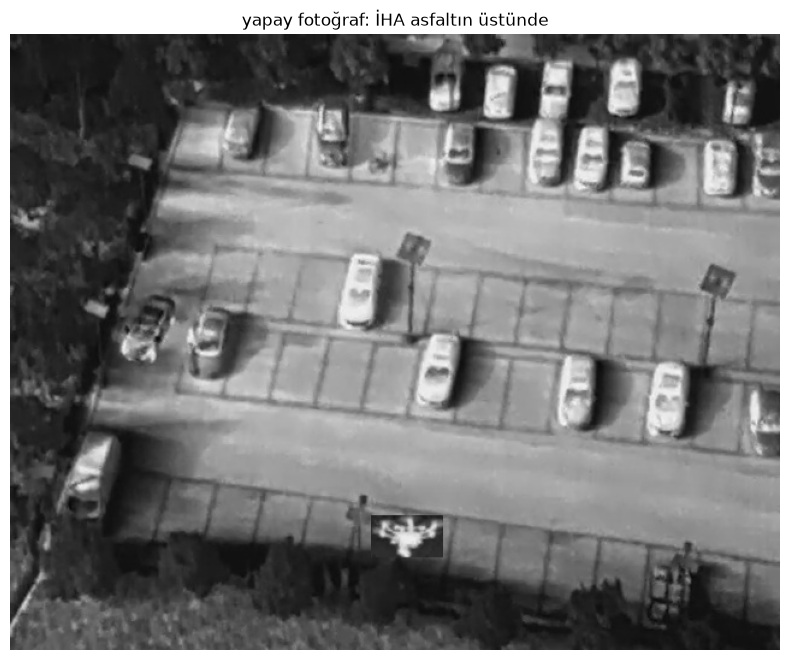

In [2]:
# --- kaynak: İHA'yı kesip alacağımız fotoğraf ---
kaynak, kaynak_kutular = oku("01_uav2uav__430__864a7aebf1")
numara, x1, y1, x2, y2 = kaynak_kutular[0]                   # ilk İHA'nın köşeleri
parca = kaynak[y1:y2, x1:x2].copy()                          # kes — [y, x] sırası, .copy() şart
ph, pw = parca.shape[0], parca.shape[1]

# --- hedef: yapıştıracağımız arka plan (İHA'nın hiç görmediği bağlam) ---
hedef, _ = oku("02_hituav__0_100_50_0_08164__c5427da128")
h_yukseklik, h_genislik = hedef.shape[0], hedef.shape[1]

yeni_x, yeni_y = 300, 400                                    # yapıştırma noktası (asfaltın ortası)
yapay = hedef.copy()
yapay[yeni_y:yeni_y+ph, yeni_x:yeni_x+pw] = parca            # yapıştır

# --- ETİKET SATIRINI YAZ: piksel → oran ---
merkez_x = (yeni_x + pw / 2) / h_genislik                    # kutunun merkezi ÷ resim genişliği
merkez_y = (yeni_y + ph / 2) / h_yukseklik
oran_g   = pw / h_genislik
oran_y   = ph / h_yukseklik

yeni_satir = f"4 {merkez_x:.6f} {merkez_y:.6f} {oran_g:.6f} {oran_y:.6f}"   # 4 = drone
print("üretilen etiket:", yeni_satir)

plt.figure(figsize=(11, 8))
plt.imshow(cv2.cvtColor(yapay, cv2.COLOR_BGR2RGB))
plt.title("yapay fotoğraf: İHA asfaltın üstünde")
plt.axis("off")
plt.show()

### 2.1 Etiketi doğrula (gidiş-dönüş kontrolü)

Etiketi biz yazdık; **yanlışsa model yanlış öğrenir** ve hiçbir hata mesajı almayız. Bu yüzden yazdığımız satırı, etiket okurken kullandığımız kodla geri çözüp kutuyu çiziyoruz. Köşeler yapıştırdığımız yerle aynı çıkmalı.

*(İlk denemede alt kenar hesabını yanlış yazmıştım ve kutu yüksekliği sıfır çıkmıştı — kod hatasız çalıştı ama etiket bozuktu. Bu adımın neden gerekli olduğunun kanıtı.)*

etiketten çözülen köşeler: 300 400 360 435
yapıştırdığımız köşeler  : 300 400 360 435


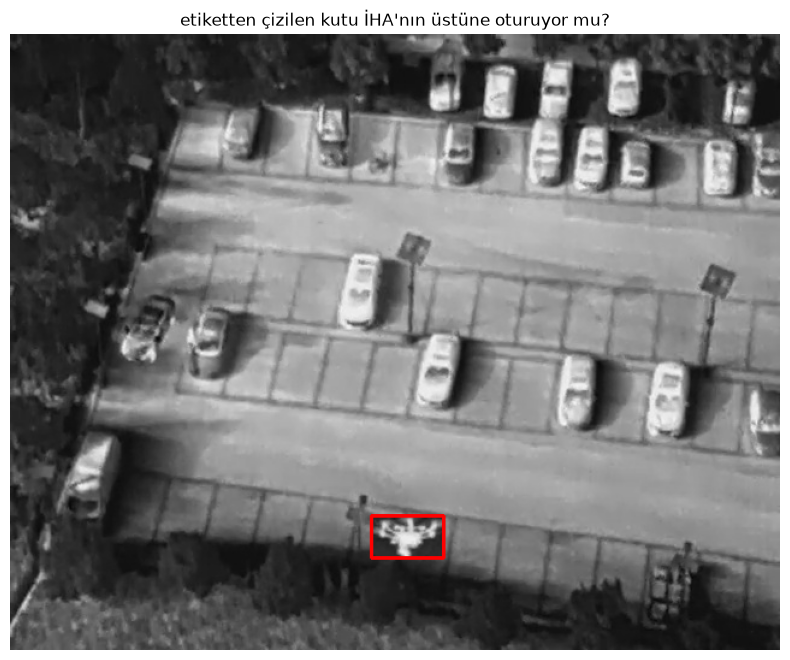

In [3]:
parcalar2 = yeni_satir.split()

merkez_x2 = float(parcalar2[1]) * h_genislik                 # oran → piksel (geri dönüşüm)
merkez_y2 = float(parcalar2[2]) * h_yukseklik
kutu_g    = float(parcalar2[3]) * h_genislik
kutu_y    = float(parcalar2[4]) * h_yukseklik

kx1 = round(merkez_x2 - kutu_g / 2)
ky1 = round(merkez_y2 - kutu_y / 2)
kx2 = round(merkez_x2 + kutu_g / 2)
ky2 = round(merkez_y2 + kutu_y / 2)

print("etiketten çözülen köşeler:", kx1, ky1, kx2, ky2)
print("yapıştırdığımız köşeler  :", yeni_x, yeni_y, yeni_x + pw, yeni_y + ph)

kontrol = yapay.copy()
cv2.rectangle(kontrol, (kx1, ky1), (kx2, ky2), (0, 0, 255), 2)
plt.figure(figsize=(11, 8))
plt.imshow(cv2.cvtColor(kontrol, cv2.COLOR_BGR2RGB))
plt.title("etiketten çizilen kutu İHA'nın üstüne oturuyor mu?")
plt.axis("off")
plt.show()

## 3. Toplu üretim

Tek İHA kullanırsak model onu ezberler. Elimizdeki bütün İHA kesitlerini topluyoruz.

toplanan İHA parçası: 60


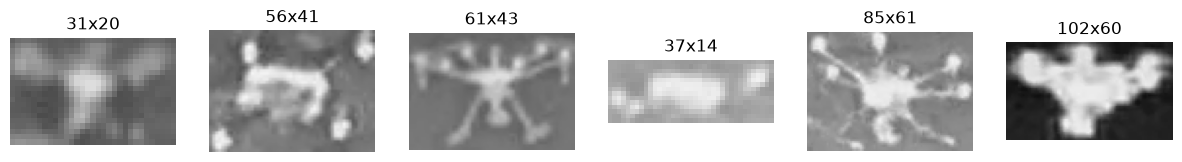

In [4]:
parcalar_listesi = []                                        # bütün İHA kesitleri

for bolum in ["train", "val", "test"]:
    for dosya_adi in os.listdir(f"{klasor}/labels/{bolum}"):
        ad = dosya_adi.replace(".txt", "")

        with open(f"{klasor}/labels/{bolum}/{dosya_adi}") as dosya:
            etiketler = dosya.read().splitlines()

        drone_satirlari = [s for s in etiketler if int(s.split()[0]) == 4]   # sınıf 4 = drone
        if not drone_satirlari:                              # drone yoksa fotoğrafı açma
            continue

        foto, kutular = oku(ad, bolum)
        for (numara, a, b, c, d) in kutular:
            if numara == 4:
                kesit = foto[b:d, a:c].copy()
                if kesit.shape[0] >= 10 and kesit.shape[1] >= 10:   # çok küçükleri alma
                    parcalar_listesi.append(kesit)

print("toplanan İHA parçası:", len(parcalar_listesi))

fig, eksenler = plt.subplots(1, 6, figsize=(15, 3))
for eksen, kesit in zip(eksenler, parcalar_listesi[:6]):
    eksen.imshow(cv2.cvtColor(kesit, cv2.COLOR_BGR2RGB))
    eksen.set_title(f"{kesit.shape[1]}x{kesit.shape[0]}")
    eksen.axis("off")
plt.show()

### 3.1 Üretici fonksiyon

Üç şey **rastgele**: arka plan, konum, boyut. Sabit kalan tek şey İHA'nın kendi görüntüsü. Böylece model konumu veya boyutu ezberleyemez, şekli öğrenmek zorunda kalır.

**Kritik ayrıntı:** arka planın kendi etiketleri korunuyor. Silseydik model oradaki arabaları "nesne yok" diye öğrenirdi.

arka plan havuzu: 217


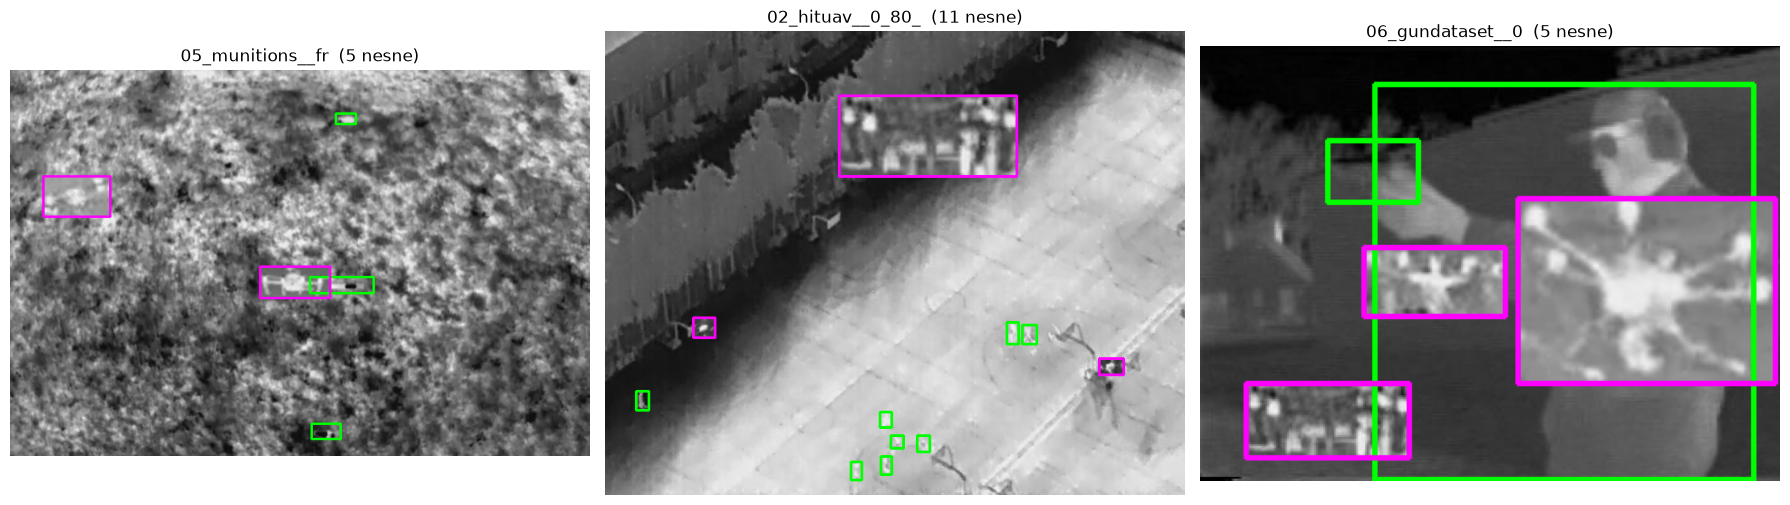

In [5]:
random.seed(0)                                               # tekrarlanabilirlik

arka_planlar = []
for dosya_adi in os.listdir(f"{klasor}/images/train"):
    if dosya_adi.startswith("01_uav2uav"):                   # gökyüzü fotoğraflarını ATLA
        continue                                             #   amacımız başka bağlamlar
    arka_planlar.append(dosya_adi.rsplit(".", 1)[0])

print("arka plan havuzu:", len(arka_planlar))


def yapay_uret(ad, iha_adedi):
    """Bir arka plana rastgele İHA'lar yapıştırır. Döndürür: fotoğraf + etiket satırları"""
    foto, _ = oku(ad)
    yukseklik, genislik = foto.shape[0], foto.shape[1]

    with open(f"{klasor}/labels/train/{ad}.txt") as dosya:
        satirlar = dosya.read().splitlines()                 # arka planın KENDİ etiketleri korunur

    yapay = foto.copy()

    for _ in range(iha_adedi):
        kesit = random.choice(parcalar_listesi)              # rastgele bir İHA

        olcek = random.uniform(0.6, 1.8)                     # rastgele boyut
        yeni_g = max(12, int(kesit.shape[1] * olcek))
        yeni_y = max(12, int(kesit.shape[0] * olcek))
        if yeni_g >= genislik or yeni_y >= yukseklik:
            continue
        kesit = cv2.resize(kesit, (yeni_g, yeni_y))          # resize (genişlik, yükseklik) ister

        x = random.randint(0, genislik - yeni_g - 1)         # rastgele konum
        y = random.randint(0, yukseklik - yeni_y - 1)
        yapay[y:y+yeni_y, x:x+yeni_g] = kesit

        merkez_x = (x + yeni_g / 2) / genislik               # piksel → oran
        merkez_y = (y + yeni_y / 2) / yukseklik
        satirlar.append(f"4 {merkez_x:.6f} {merkez_y:.6f} {yeni_g/genislik:.6f} {yeni_y/yukseklik:.6f}")

    return yapay, satirlar


# --- 3 örnek üret ve etiketleriyle birlikte doğrula ---
fig, eksenler = plt.subplots(1, 3, figsize=(18, 5))
for eksen in eksenler:
    ad = random.choice(arka_planlar)
    yapay, satirlar = yapay_uret(ad, random.randint(1, 3))

    cizim = yapay.copy()
    h, w = cizim.shape[0], cizim.shape[1]
    for satir in satirlar:
        p = satir.split()
        n = int(p[0])
        mx, my = float(p[1]) * w, float(p[2]) * h
        g, y_ = float(p[3]) * w, float(p[4]) * h
        renk = (255, 0, 255) if n == 4 else (0, 255, 0)      # drone mor, diğerleri yeşil
        cv2.rectangle(cizim, (round(mx-g/2), round(my-y_/2)), (round(mx+g/2), round(my+y_/2)), renk, 2)

    eksen.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
    eksen.set_title(f"{ad[:16]}  ({len(satirlar)} nesne)")
    eksen.axis("off")
plt.tight_layout()
plt.show()

## 4. Kaggle'da büyük ölçekli üretim ve eğitim

Yukarıdaki yöntem Kaggle'da tam veri setiyle uygulandı. Aşağıdaki kod orada çalıştırıldı, burada kayıt olarak duruyor.

**Deney tasarımı — tek değişken:**

| | v1 | **v3** |
|---|---|---|
| Gerçek fotoğraf | 3.000 | 3.000 (**aynı dosyalar**, `random.seed(42)`) |
| Yapay fotoğraf | 0 | **1.500** |
| Model, epoch, batch, imgsz | yolo11n, 20, 32, 640 | **hepsi aynı** |

```python
# --- 800 İHA kesiti topla (Kaggle train bölümünden) ---
parcalar_listesi = []
dosyalar = sorted(os.listdir(kok + "/labels/train"))
random.seed(1); random.shuffle(dosyalar)                  # hep aynı videodan gelmesin

for dosya_adi in dosyalar:
    if len(parcalar_listesi) >= 800:                      # yeterince topladıysak dur
        break
    etiketler = open(kok + "/labels/train/" + dosya_adi).read().splitlines()
    drone_satirlari = [s for s in etiketler if int(s.split()[0]) == 4]
    if not drone_satirlari:
        continue
    ad = dosya_adi.replace(".txt", "")
    foto = cv2.imread(kok + "/images/train/" + ad + ".png")
    if foto is None:
        continue
    yukseklik, genislik = foto.shape[0], foto.shape[1]
    for satir in drone_satirlari:
        p = satir.split()
        mx, my = float(p[1]) * genislik, float(p[2]) * yukseklik
        g,  y  = float(p[3]) * genislik, float(p[4]) * yukseklik
        kesit = foto[round(my-y/2):round(my+y/2), round(mx-g/2):round(mx+g/2)].copy()
        if kesit.shape[0] >= 10 and kesit.shape[1] >= 10:
            parcalar_listesi.append(kesit)

# --- 1.500 yapay fotoğraf üret ---
random.seed(7)
for i in range(1500):
    ad = random.choice(arka_planlar)                      # gökyüzü OLMAYAN arka planlar
    foto = cv2.imread(hedef + "/images/train/" + ad + ".png")
    yukseklik, genislik = foto.shape[0], foto.shape[1]
    satirlar = open(hedef + "/labels/train/" + ad + ".txt").read().splitlines()   # mevcut etiketler korunur
    yapay = foto.copy()

    for _ in range(random.randint(1, 3)):                 # 1-3 İHA
        kesit = random.choice(parcalar_listesi)
        olcek = random.uniform(0.6, 1.8)
        yeni_g = max(12, int(kesit.shape[1] * olcek))
        yeni_y = max(12, int(kesit.shape[0] * olcek))
        kesit = cv2.resize(kesit, (yeni_g, yeni_y))
        x = random.randint(0, genislik - yeni_g - 1)
        y = random.randint(0, yukseklik - yeni_y - 1)
        yapay[y:y+yeni_y, x:x+yeni_g] = kesit
        satirlar.append(f"4 {(x+yeni_g/2)/genislik:.6f} {(y+yeni_y/2)/yukseklik:.6f} "
                        f"{yeni_g/genislik:.6f} {yeni_y/yukseklik:.6f}")

    yeni_ad = f"yapay_{i:05d}"
    cv2.imwrite(hedef + "/images/train/" + yeni_ad + ".png", yapay)          # gerçek dosya yaz
    open(hedef + "/labels/train/" + yeni_ad + ".txt", "w").write("\n".join(satirlar) + "\n")

# --- eğitim (v1 ile birebir aynı ayarlar) ---
model = YOLO("yolo11n.pt")
model.train(data="/kaggle/working/data_v3.yaml", epochs=20, imgsz=640,
            batch=32, device=0, project="/kaggle/working/egitim", name="deneme3_yapay")
```

**Eğitim seti:** 3.000 gerçek + 1.500 yapay = 4.500 fotoğraf. Süre ~35 dakika (Tesla T4).

### 4.1 Doğrulama setindeki sonuçlar

| | v1 (yapay yok) | v3 (yapay var) |
|---|---|---|
| mAP50 | 0.789 | 0.797 |
| mAP50-95 | 0.554 | 0.560 |
| drone | 0.938 | 0.919 |
| bicycle | 0.627 | 0.700 |

Genel sonuç neredeyse aynı, `drone` biraz düşmüş. **Beklenen bir durum:** doğrulama seti yalnızca gerçek gökyüzü İHA'larından oluşuyor, biz ise modele başka bağlamlar da öğrettik.

**Asıl soru bu tabloda görünmez.** Onu kendi testlerimizle ölçüyoruz.

## 5. TEST 1 — Farklı arka planlarda tek kare

Aynı İHA parçası, beş farklı sahne. Nesne birebir aynı, değişen tek şey arka plan.

In [6]:
v1 = YOLO("../models/iha_yolo11n.pt")          # 3.000 gerçek
v2 = YOLO("../models/iha_yolo11n_v2.pt")       # 10.000 gerçek, 40 epoch
v3 = YOLO("../models/iha_yolo11n_v3.pt")       # 3.000 gerçek + 1.500 YAPAY

iha, ks = oku("01_uav2uav__430__864a7aebf1")
parca = iha[ks[0][2]:ks[0][4], ks[0][1]:ks[0][3]].copy()
ph, pw = parca.shape[0], parca.shape[1]

otopark, _ = oku("02_hituav__0_100_50_0_08164__c5427da128")
sokak, _   = oku("03_llvip__120019__91781a1c2d")

sahneler = {}
k = otopark.copy(); k[400:400+ph, 300:300+pw] = parca
sahneler["otopark asfalt"] = (k, (300, 400, 300+pw, 400+ph))
k = otopark.copy(); k[250:250+ph, 260:260+pw] = parca
sahneler["otopark parlak"] = (k, (260, 250, 260+pw, 250+ph))
k = sokak.copy();   k[100:100+ph, 300:300+pw] = parca
sahneler["sokak"] = (k, (300, 100, 300+pw, 100+ph))
duz = np.full((512, 640, 3), 30, np.uint8); duz[240:240+ph, 290:290+pw] = parca
sahneler["düz koyu tuval"] = (duz, (290, 240, 290+pw, 240+ph))
sahneler["orijinal gökyüzü"] = (iha, (ks[0][1], ks[0][2], ks[0][3], ks[0][4]))


def dene(model, resim, bolge, conf=0.25):
    """Yapıştırdığımız bölgedeki tahmini döndürür"""
    sonuc = model(resim, verbose=False, conf=conf)[0]
    bx1, by1, bx2, by2 = bolge
    yakin = [(model.names[int(k.cls)], round(float(k.conf), 2)) for k in sonuc.boxes
             if k.xyxy[0][0] < bx2+20 and k.xyxy[0][2] > bx1-20
             and k.xyxy[0][1] < by2+20 and k.xyxy[0][3] > by1-20]
    drone = [c for c in yakin if c[0] == "drone"]
    return f"drone {drone[0][1]}" if drone else ("—" if not yakin else f"{yakin[0][0]} {yakin[0][1]}")


print(f"{'SAHNE':20} {'v1':>14} {'v2':>14} {'v3 (yapay)':>14}")
print("-" * 66)
for ad, (im, bolge) in sahneler.items():
    print(f"{ad:20} {dene(v1,im,bolge):>14} {dene(v2,im,bolge):>14} {dene(v3,im,bolge):>14}")

SAHNE                            v1             v2     v3 (yapay)
------------------------------------------------------------------


otopark asfalt                    —              —     drone 0.95
otopark parlak             car 0.93        car 0.9     drone 0.95


sokak                             —              —     drone 0.93
düz koyu tuval           drone 0.91     drone 0.88     drone 0.93


orijinal gökyüzü         drone 0.86     drone 0.88     drone 0.89


**Sonuç:** v1 ve v2 İHA'yı yalnızca düz koyu zeminde ve orijinal gökyüzünde buluyor. v3 **beş sahnenin hepsinde** buluyor, üstelik eski yeteneğini kaybetmeden (gökyüzü 0.86 → 0.89).

Dikkat: "otopark parlak" satırında v1 ve v2 oraya **`car`** diyor. Yani nesneyi görüyor ama sınıfı **sahneye bakarak** seçiyor.

## 6. TEST 2 — Video: 100 kare

Tek kare tesadüf olabilir. Aynı İHA'yı otopark arka planında 100 kare boyunca hareket ettiriyoruz.

In [7]:
for isim, model in [("v1", v1), ("v2", v2), ("v3", v3)]:
    bulunan = 0
    for i in range(100):                                     # 100 kare
        kare = otopark.copy()
        x = 20 + int(i * (640 - pw - 40) / 100)              # soldan sağa
        y = 60 + int(i * 320 / 100)                          # yukarıdan aşağı
        kare[y:y+ph, x:x+pw] = parca
        sonuc = model(kare, verbose=False)[0]
        if any(model.names[int(k.cls)] == "drone" for k in sonuc.boxes):
            bulunan += 1
    print(f"{isim}: 100 karenin {bulunan} tanesinde drone bulundu")

v1: 100 karenin 1 tanesinde drone bulundu


v2: 100 karenin 0 tanesinde drone bulundu


v3: 100 karenin 100 tanesinde drone bulundu


**Sonuç: v1 → 1/100, v2 → 0/100, v3 → 100/100.**

## 7. TEST 3 — Görülmemiş İHA'lar (genelleme testi)

En kritik test: model **o tek İHA'yı mı** ezberledi, yoksa genel olarak İHA'yı mı öğrendi?

Yapay veri üretilirken yalnızca **train** bölümü tarandı. Burada **val ve test** bölümünden 8 farklı İHA kesiti kullanıyoruz — model bunları hiç görmedi.

In [8]:
# val/test bölümünden farklı İHA kesitleri
kesitler = []
for bolum in ["val", "test"]:
    for d in sorted(os.listdir(f"{klasor}/labels/{bolum}")):
        if not d.startswith("01_uav2uav"):
            continue
        ad = d[:-4]
        foto, kutular = oku(ad, bolum)
        for (n, a, b, c, e) in kutular:
            if n == 4 and (e-b) >= 14 and (c-a) >= 14:
                kesitler.append(foto[b:e, a:c].copy())

adaylar = [d.rsplit(".", 1)[0] for d in sorted(os.listdir(f"{klasor}/images/train"))
           if not d.startswith("01_uav2uav")]
random.seed(21)
arka_secim = random.sample(adaylar, 3)

def genelleme_testi(model):
    bulundu = toplam = 0
    skorlar = []
    for i, kesit in enumerate(kesitler[:8]):                 # 8 farklı İHA
        for j, arka_ad in enumerate(arka_secim):             # 3 farklı arka plan
            arka, _ = oku(arka_ad)
            h, w = arka.shape[0], arka.shape[1]
            kh, kw = kesit.shape[0], kesit.shape[1]
            if kh >= h-30 or kw >= w-30:
                continue
            random.seed(900 + i*10 + j)
            x = random.randint(15, w-kw-15)
            y = random.randint(15, h-kh-15)
            im = arka.copy(); im[y:y+kh, x:x+kw] = kesit
            sonuc = model(im, verbose=False)[0]
            toplam += 1
            d = [float(k.conf) for k in sonuc.boxes if model.names[int(k.cls)] == "drone"
                 and k.xyxy[0][0] < x+kw+20 and k.xyxy[0][2] > x-20
                 and k.xyxy[0][1] < y+kh+20 and k.xyxy[0][3] > y-20]
            if d:
                bulundu += 1; skorlar.append(max(d))
    ort = sum(skorlar)/len(skorlar) if skorlar else 0
    return bulundu, toplam, ort

print("kullanılan farklı İHA kesiti:", len(kesitler))
for isim, model in [("v1", v1), ("v3", v3)]:
    b, t, ort = genelleme_testi(model)
    print(f"{isim}: {t} denemenin {b} tanesinde drone bulundu (ortalama güven {ort:.2f})")

kullanılan farklı İHA kesiti: 23


v1: 24 denemenin 5 tanesinde drone bulundu (ortalama güven 0.52)


v3: 24 denemenin 23 tanesinde drone bulundu (ortalama güven 0.95)


**Sonuç: v1 → 5/24 (güven 0.52), v3 → 23/24 (güven 0.95).**

Model tek bir görüntüyü ezberlemedi; hiç görmediği İHA'ları, hiç görmediği arka planlarda tanıyor. Genelleme gerçekleşti.

## 8. TEST 4 — Ters yön: yan etki var mı?

Kestirmeyi kırdık, peki **bedeli** ne oldu? Bu sefer tersini deniyoruz: **araba** kesitlerini **gökyüzüne** yapıştırıyoruz.

In [9]:
# araba kesitleri (val/test'ten)
arabalar = []
for bolum in ["val", "test"]:
    for d in sorted(os.listdir(f"{klasor}/labels/{bolum}")):
        ad = d[:-4]
        foto, kutular = oku(ad, bolum)
        for (n, a, b, c, e) in kutular:
            if n == 1 and (e-b) >= 25 and (c-a) >= 25:       # 1 = car
                arabalar.append(foto[b:e, a:c].copy())

gokyuzu = [d.rsplit(".", 1)[0] for d in sorted(os.listdir(f"{klasor}/images/train"))
           if d.startswith("01_uav2uav")]

def ters_test(model, kesitler, arkalar, beklenen="car"):
    dogru = toplam = 0
    digerleri = {}
    for i, kesit in enumerate(kesitler[:8]):
        for j, arka_ad in enumerate(arkalar[:3]):
            arka, _ = oku(arka_ad)
            h, w = arka.shape[0], arka.shape[1]
            kh, kw = kesit.shape[0], kesit.shape[1]
            if kh >= h-30 or kw >= w-30:
                continue
            random.seed(700 + i*10 + j)
            x = random.randint(15, w-kw-15); y = random.randint(15, h-kh-15)
            im = arka.copy(); im[y:y+kh, x:x+kw] = kesit
            sonuc = model(im, verbose=False)[0]
            toplam += 1
            yakin = [model.names[int(k.cls)] for k in sonuc.boxes
                     if k.xyxy[0][0] < x+kw+20 and k.xyxy[0][2] > x-20
                     and k.xyxy[0][1] < y+kh+20 and k.xyxy[0][3] > y-20]
            if beklenen in yakin:
                dogru += 1
            else:
                anahtar = yakin[0] if yakin else "—"
                digerleri[anahtar] = digerleri.get(anahtar, 0) + 1
    return dogru, toplam, digerleri

print("=== ARABA → GÖKYÜZÜ ===")
for isim, model in [("v1", v1), ("v3", v3)]:
    d, t, dg = ters_test(model, arabalar, gokyuzu)
    print(f"{isim}: {t} denemenin {d} tanesinde 'car' | diğer tahminler: {dg}")

=== ARABA → GÖKYÜZÜ ===


v1: 24 denemenin 11 tanesinde 'car' | diğer tahminler: {'drone': 4, '—': 9}


v3: 24 denemenin 2 tanesinde 'car' | diğer tahminler: {'drone': 17, '—': 5}


**Sonuç: v1 → 11/24 `car`, v3 → 2/24 `car` (17 kez `drone` dedi).**

Burada **iki ayrı kestirme** olduğu ortaya çıkıyor:

| Kestirme | Durum |
|---|---|
| A: "İHA sadece gökyüzünde bulunur" | ✅ **kırıldı** (Test 1, 2, 3) |
| B: "Gökyüzünde bir şey varsa o İHA'dır" | ❌ **kırılmadı**, hatta güçlendi |

Sebep: ürettiğimiz 1.500 yapay fotoğrafın hepsinde yapıştırılan nesne **İHA'ydı**. Modele "farklı arka planlarda İHA olabilir" dedik ama "gökyüzünde İHA olmayan şeyler de olabilir" demedik.

Karışıklık matrisinde de görünüyordu: `drone` için yanlış alarm **8'den 28'e** çıkmış.

## 9. Görsel karşılaştırmalar

Aşağıdaki görseller `egitim_sonuclari/deneyler/` klasöründe kayıtlı. Her satırda **solda v1**, **sağda v3**, aynı fotoğraf. **Sarı ince çerçeve** yapıştırdığımız İHA'nın gerçek yerini gösterir.

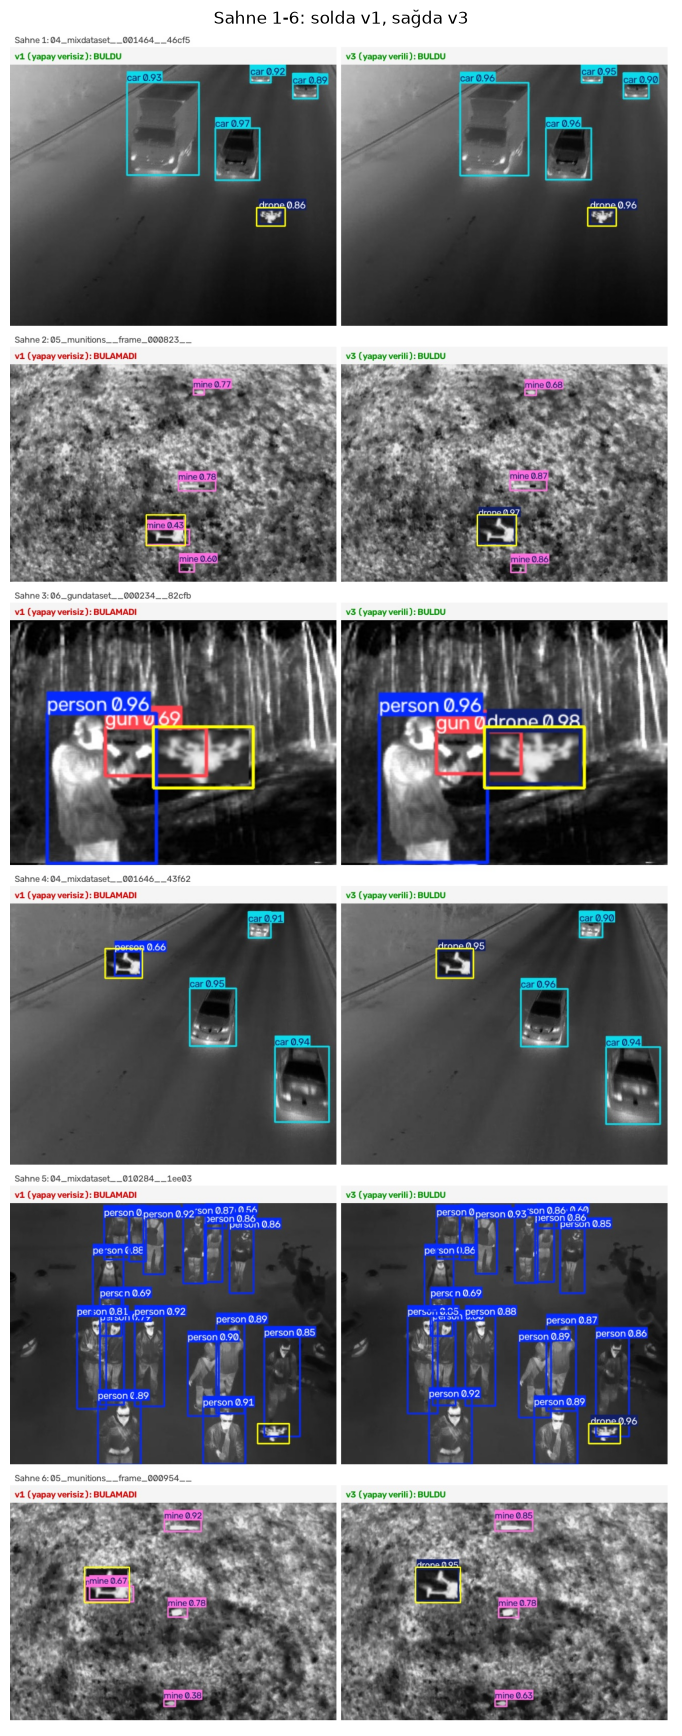

In [10]:
def gorsel(dosya, baslik, boyut=(16, 22)):
    resim = plt.imread("../egitim_sonuclari/deneyler/" + dosya)
    plt.figure(figsize=boyut)
    plt.imshow(resim)
    plt.title(baslik)
    plt.axis("off")
    plt.show()

gorsel("yanyana_1.jpg", "Sahne 1-6: solda v1, sağda v3")

**Öne çıkanlar (1. grup):**

| Sahne | v1'in tahmini | v3'ün tahmini |
|---|---|---|
| 1 — yol, kuşbakışı | drone 0.86 ✅ | drone 0.96 ✅ |
| 2 — mayın sahası | **mine 0.43** ❌ | drone 0.97 ✅ |
| 3 — ağaçlık, silahlı kişi | bulamadı ❌ | drone 0.98 ✅ |
| 4 — yol, araçlar | **person 0.66** ❌ | drone 0.95 ✅ |
| 5 — kalabalık (15 insan) | bulamadı ❌ | drone 0.96 ✅ |
| 6 — benekli toprak | **mine 0.67** ❌ | drone 0.95 ✅ |

Buradaki ince bulgu: v1 çoğu zaman İHA'yı **hiç görmüyor değil** — orada bir nesne olduğunu fark ediyor ama **sınıfı sahneye bakarak** seçiyor. Mayın sahasında `mine`, yolda `person`, otoparkta `car` diyor. v3'te bu bağımlılık kırılmış.

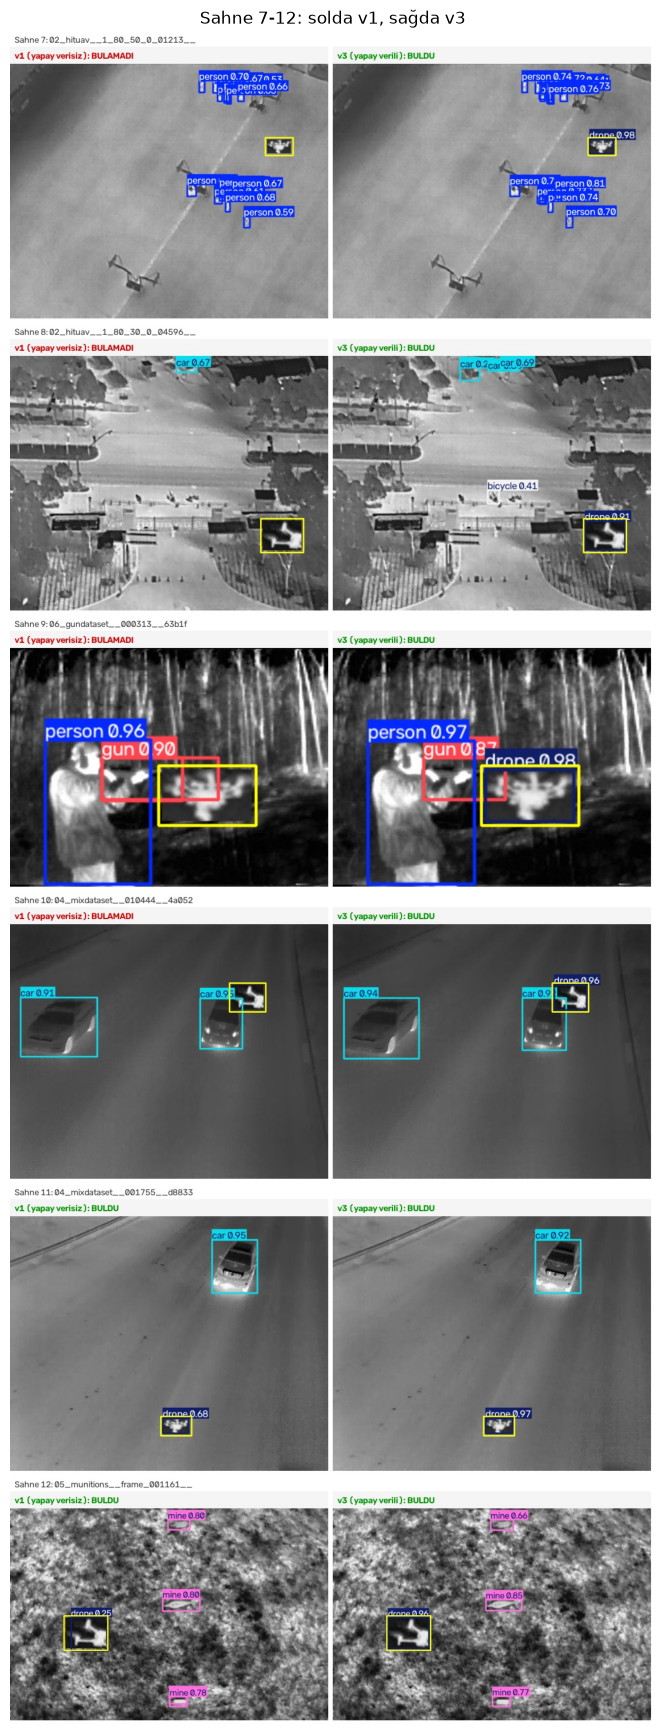

In [11]:
gorsel("yanyana_2.jpg", "Sahne 7-12: solda v1, sağda v3")

### 9.1 Genelleme testinin görselleri

Aşağıdaki 6 İHA kesiti **val ve test** bölümünden geliyor; yapay veri üretilirken yalnızca **train** bölümü tarandığı için model bunları hiç görmedi.

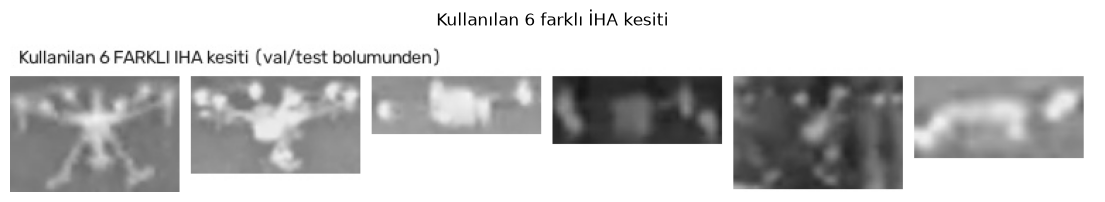

In [12]:
gorsel("farkli_ihalar.jpg", "Kullanılan 6 farklı İHA kesiti", (14, 3))

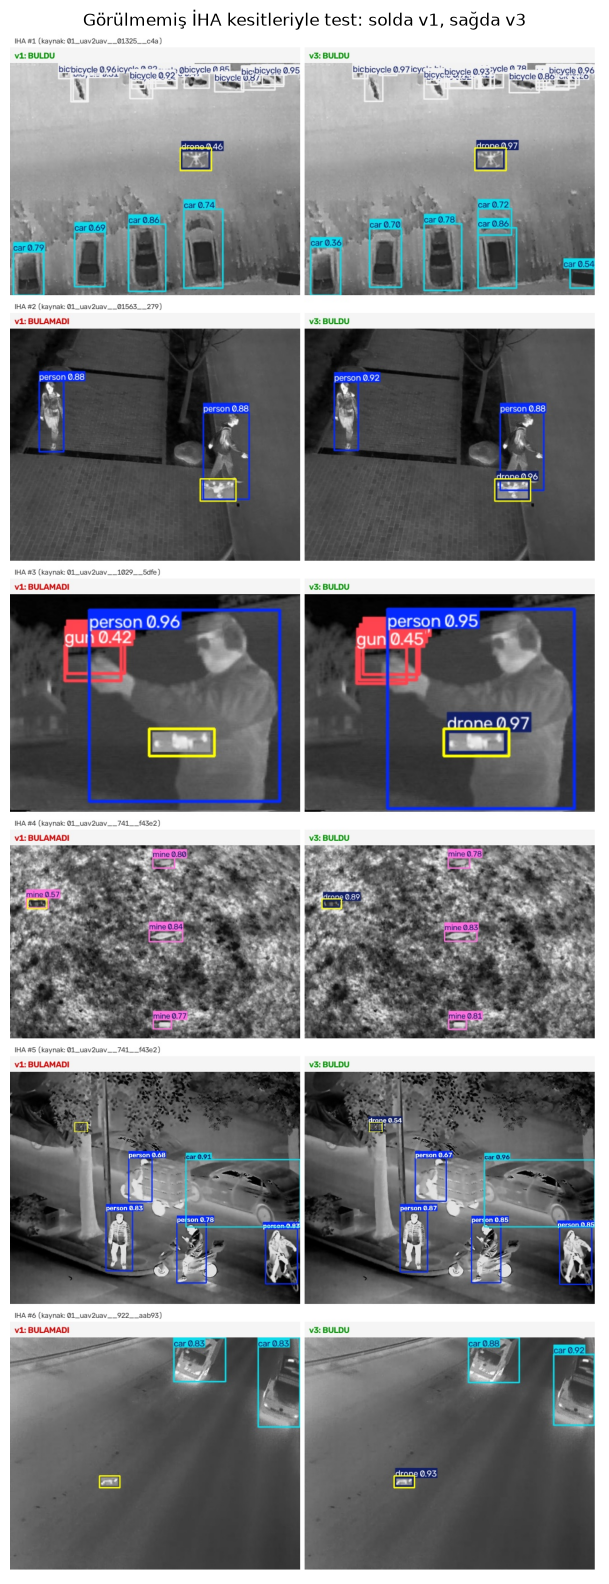

In [13]:
gorsel("farkli_iha_testi.jpg", "Görülmemiş İHA kesitleriyle test: solda v1, sağda v3", (16, 20))

## Sonuç

### Başarılan

| Test | v1 | **v3** |
|---|---|---|
| İHA farklı arka planlarda (5 sahne) | 2/5 | **5/5** |
| Video, otopark arka planı (100 kare) | 1/100 | **100/100** |
| Görülmemiş İHA kesitleri (24 deneme) | 5/24 | **23/24** |
| Doğrulama mAP50 | 0.789 | 0.797 |

Kestirme öğrenme kırıldı, üstelik **daha fazla gerçek veri toplamadan** ve genel başarıyı düşürmeden.

### Yan etki

Model artık gökyüzündeki her nesneyi İHA sanmaya daha yatkın (`car` → `drone` karışması, yanlış alarmın artması). Precision–recall dengesinin klasik takası: kaçırma azaldı, yanlış alarm arttı.

Bir savunma uygulaması için bu takas kabul edilebilir (kaçırmanın maliyeti daha yüksektir), ama bilinerek kabul edilmeli.

### Sonraki adım: karşı örnekler

Bir kestirmeyi tam olarak kırmak için **iki yönlü** örnek gerekiyor:

| Ürettiğimiz | Eksik olan |
|---|---|
| İHA → otopark, sokak, toprak | **Araba, insan, bisiklet → gökyüzü** |

Gökyüzüne araba yapıştırıp etiketine `1` (car) yazmak. Böylece "gökyüzü = drone" denklemi de kırılır.

### Yöntemin sınırları

- Yapıştırma kenarları keskin; model "keskin kenarlı yama" gibi yeni bir kestirme öğrenebilir
- Işık ve gölge uyumsuz, fizik yok
- Bütün kesitler aynı veri setinden, yani aynı kamera ve çekim koşullarından geliyor. Tamamen farklı bir kaynaktan gelen görüntüde davranışı test edilmedi.